In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
# import gpax
# import jax.numpy as jnp
# import jax.random as jra
# import matplotlib.pyplot as plt

# # --- 1. CONFIGURATION & DATA GENERATION ---
# key_train, key_mc = gpax.utils.get_keys()

# # Ground truth: y depends on Control(x1, x2) and Random Covariate(c)
# def ground_truth(x):
#     # A function where 'c' significantly shifts the position of the best x
#     return (jnp.sin(10 * x[:, 0]) * jnp.cos(10 * x[:, 1])) + (x[:, 2] * 2.0 * x[:, 0])

# # Generate training data
# n_train = 25
# X_train = jra.uniform(key_train, (n_train, 3))
# y_train = ground_truth(X_train)
# y_train_norm = (y_train - y_train.mean()) / y_train.std()

# # --- 2. MODEL TRAINING ---
# # Train on full 3D data (x1, x2, c)
# model = gpax.ExactGP(input_dim=3, kernel='Matern')
# model.fit(key_train, X_train, y_train_norm, num_chains=1, num_samples=250)

# # --- 3. ROBUST ACQUISITION SETUP ---

# # A. Create the grid for X (Control variables only)
# resolution = 40
# x1_lin = jnp.linspace(0, 1, resolution)
# x2_lin = jnp.linspace(0, 1, resolution)
# X1, X2 = jnp.meshgrid(x1_lin, x2_lin)
# # Shape: (1600, 2)
# X_grid_2d = jnp.column_stack([X1.ravel(), X2.ravel()])

# # B. Sample the Covariate Distribution (Monte Carlo)
# # We assume the future 'c' will behave like the 'c' we observed in training.
# # We draw 20 random samples of 'c' to average over.
# n_mc_samples = 20
# c_history = X_train[:, 2] # The column of observed covariates
# c_samples = jra.choice(key_mc, c_history, shape=(n_mc_samples,), replace=True)

# # --- 4. BATCHED INTEGRATION (The "Robust" Step) ---

# def compute_robust_acq(key, model, X_grid, c_samples):
#     # X_grid shape: (N_grid, 2)
#     # c_samples shape: (N_mc,)

#     n_grid = X_grid.shape[0]
#     n_mc = c_samples.shape[0]

#     # We need to evaluate every x against every c.
#     # Total evaluations = N_grid * N_mc = 1600 * 20 = 32,000 evaluations.

#     # 1. Repeat X_grid for each MC sample
#     # Shape becomes (N_grid * N_mc, 2)
#     # [x1, x1, ... x2, x2, ...]
#     X_repeated = jnp.repeat(X_grid, n_mc, axis=0)

#     # 2. Tile c_samples for the whole grid
#     # Shape becomes (N_grid * N_mc, 1)
#     # [c1, c2, ... c1, c2, ...]
#     c_tiled = jnp.tile(c_samples, n_grid)[:, None]

#     # 3. Stack to create (N_grid * N_mc, 3) input
#     X_full_batch = jnp.hstack([X_repeated, c_tiled])

#     # 4. Compute Acquisition in chunks to save memory
#     # We process 1000 items at a time
#     batch_size = 1000
#     n_total = X_full_batch.shape[0]
#     acq_list = []

#     print(f"Calculating robust acquisition over {n_total} scenarios...")

#     for i in range(0, n_total, batch_size):
#         batch_X = X_full_batch[i : i + batch_size]
#         key, subkey = jra.split(key)

#         # Standard EI calculation on this batch
#         acq_batch = gpax.acquisition.EI(
#             subkey, model, batch_X, best_f=y_train_norm.max(), maximize=True
#         )
#         acq_list.append(acq_batch)

#     # Combine results: Shape (N_grid * N_mc, )
#     all_acq_values = jnp.concatenate(acq_list)

#     # 5. Reshape and Average
#     # Reshape to (N_grid, N_mc) so we can average across the MC dimension
#     all_acq_matrix = all_acq_values.reshape(n_grid, n_mc)

#     # Take the mean across axis 1 (integrating out c)
#     robust_acq = jnp.mean(all_acq_matrix, axis=1)

#     return robust_acq

# # Execute
# robust_acq_values = compute_robust_acq(key_pred, model, X_grid_2d, c_samples)

# # --- 5. PLOTTING ---
# robust_map = robust_acq_values.reshape(resolution, resolution)
# best_idx = jnp.argmax(robust_acq_values)

# plt.figure(figsize=(10, 8))
# contour = plt.contourf(X1, X2, robust_map, levels=50, cmap='plasma')
# plt.colorbar(contour, label='Integrated Expected Improvement')

# # Plot best robust point
# plt.scatter(X_grid_2d[best_idx, 0], X_grid_2d[best_idx, 1],
#             c='lime', marker='*', s=300, edgecolors='black', label='Best Robust Point')

# # Plot training data (projected to 2D)
# plt.scatter(X_train[:, 0], X_train[:, 1], c='black', alpha=0.5, label='Training Data')

# plt.title('Robust Acquisition Landscape\n(Averaged over random covariate noise)')
# plt.xlabel('x1'); plt.ylabel('x2')
# plt.legend()
# plt.show()

In [2]:
import os
import time
from rtm_pymmcore.data_structures import Channel, StimTreatment, SegmentationMethod
import rtm_pymmcore.utils as utils
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
import gpax
import pandas as pd

In [3]:
from rtm_pymmcore.agents.bo_optimization_gpax import (
    BOptGPAX,
    BO_Parameter,
    BO_Objective,
    StandardScalerBounds,
    BO_Covariate,
    mock_df_results,
)

      x1   x2      cov1           y
0    0.0  6.0  0.773956   85.931203
1    0.0  6.0  0.438878  101.332991
2    0.0  6.0  0.858598   78.676903
3    0.0  6.0  0.697368   90.508233
4    0.0  6.0  0.094177  115.111551
5    0.0  6.0  0.975622   68.803850
6    0.0  6.0  0.761140   84.763823
7    0.0  6.0  0.786064   78.765980
8    0.0  6.0  0.128114  114.673397
9    0.0  6.0  0.450386   98.418576
10  10.0  0.0  0.758088  168.173593
11  10.0  0.0  0.354526  140.108507
12  10.0  0.0  0.970698  167.880031
13  10.0  0.0  0.893121  163.519167
14  10.0  0.0  0.778383  163.746911
15  10.0  0.0  0.194639  135.531838
16  10.0  0.0  0.466721  146.523219
17  10.0  0.0  0.043804  122.828059
18  10.0  0.0  0.154289  128.756891
19  10.0  0.0  0.683049  159.404510
20   0.0  0.0  0.437152  116.863109
21   0.0  0.0  0.832678  110.008180
22   0.0  0.0  0.700265  112.729447
23   0.0  0.0  0.312367  117.706883
24   0.0  0.0  0.832260  104.427392
25   0.0  0.0  0.804764  109.047120
26   0.0  0.0  0.387478  114

sample: 100%|██████████| 1200/1200 [00:00<00:00, 1316.64it/s, 7 steps of size 5.35e-01. acc. prob=0.94] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.80      0.58      0.66      0.11      1.68    666.88      1.00
k_length[1]      1.63      1.40      1.30      0.05      3.44    816.59      1.00
k_length[2]      4.09      1.41      3.89      1.86      6.01    819.68      1.00
    k_scale      1.60      1.02      1.33      0.39      2.78    688.38      1.00
      noise      0.02      0.01      0.02      0.01      0.03    483.15      1.00

Computing robust acquisition over 1480 scenarios (74 grid points × 20 covariate samples)...
  best_f (scaled): 1.840921
  Acq values stats: min=0.000000, max=0.159198, mean=0.033070
  Robust acq stats: min=0.000017, max=0.093743
Computing robust acquisition over 1540 scenarios (77 grid points × 20 covariate samples)...
  best_f (scaled): 1.840921
  Acq values stats: min=0.000000, max=0.157907, mean=0.031656
  Robust acq stats: min=0.000000, max=0.093752


c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\rtm_pymmcore\agents\bo_optimization_gpax.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


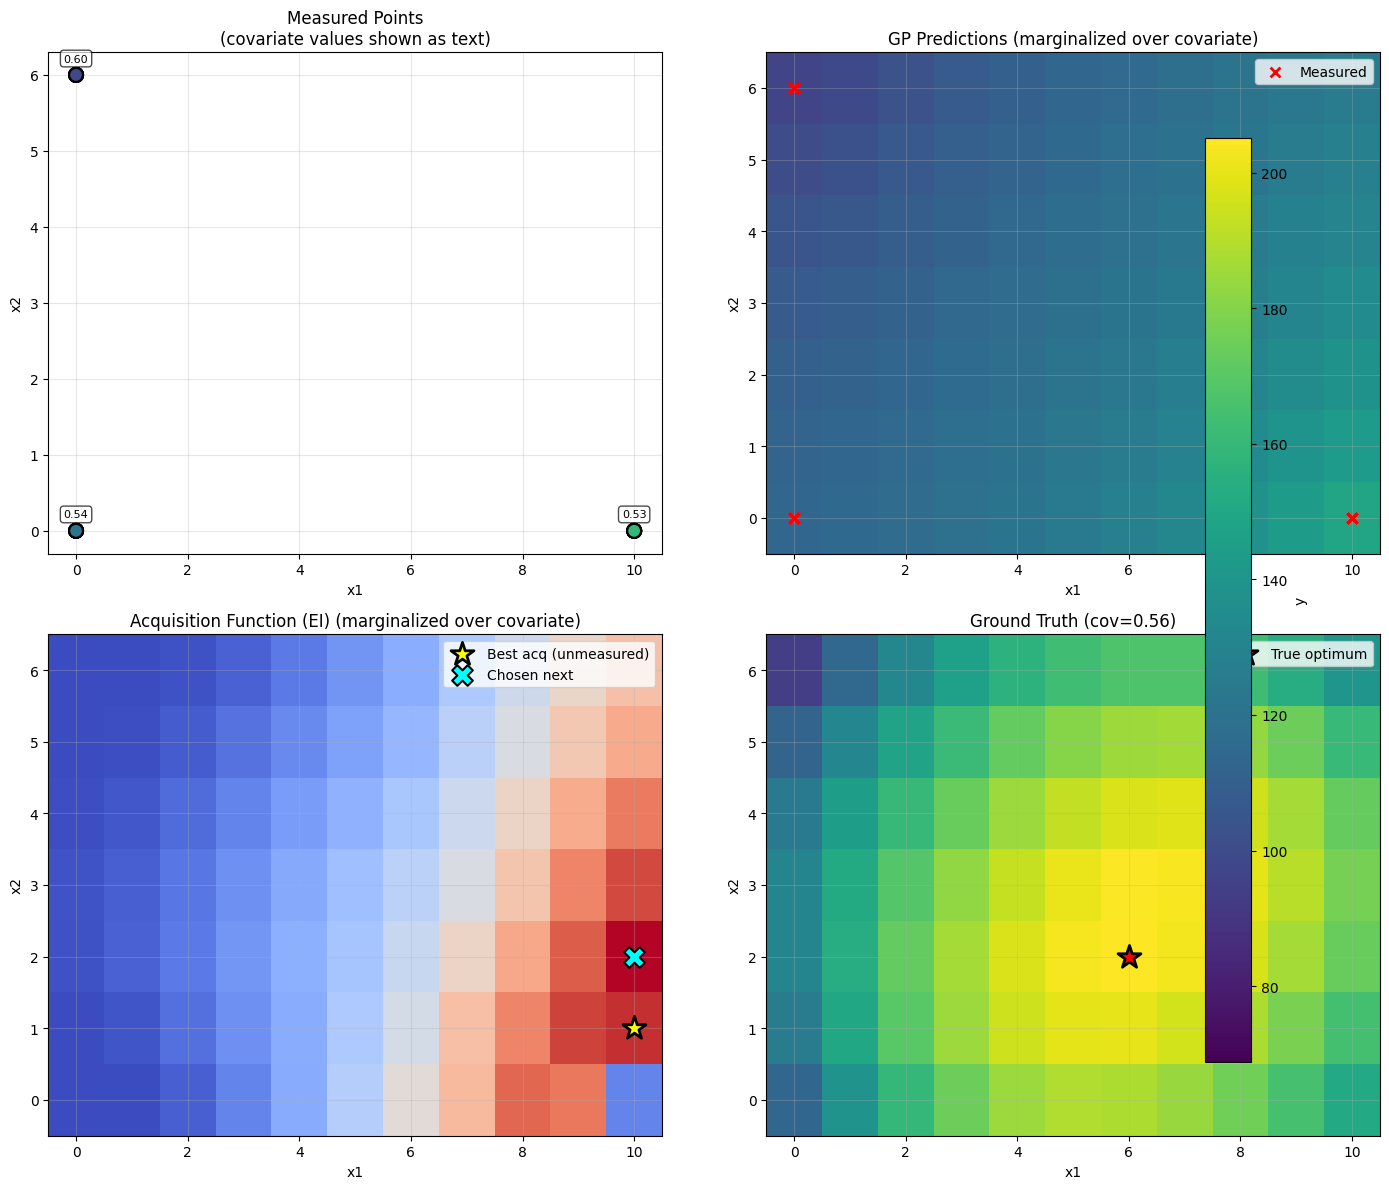

{'x1': np.float64(10.0), 'x2': np.float64(2.0)}
=== BO iteration 2/12 ===


sample: 100%|██████████| 1200/1200 [00:02<00:00, 490.61it/s, 15 steps of size 3.73e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.78      0.57      0.63      0.11      1.58    704.88      1.00
k_length[1]      1.46      0.81      1.35      0.20      2.57    776.11      1.00
k_length[2]      5.44      1.60      5.17      2.89      7.79    547.28      1.00
    k_scale      1.55      0.92      1.32      0.38      2.74    502.14      1.00
      noise      0.01      0.00      0.01      0.01      0.01   1098.57      1.00

Computing robust acquisition over 1460 scenarios (73 grid points × 20 covariate samples)...
  best_f (scaled): 1.489406
  Acq values stats: min=0.000000, max=0.183103, mean=0.047444
  Robust acq stats: min=0.000002, max=0.165715
Computing robust acquisition over 1540 scenarios (77 grid points × 20 covariate samples)...
  best_f (scaled): 1.489406
  Acq values stats: min=0.000000, max=0.178555, mean=0.043138
  Robust acq stats: min=0.000000, max=0.159795


c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\rtm_pymmcore\agents\bo_optimization_gpax.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


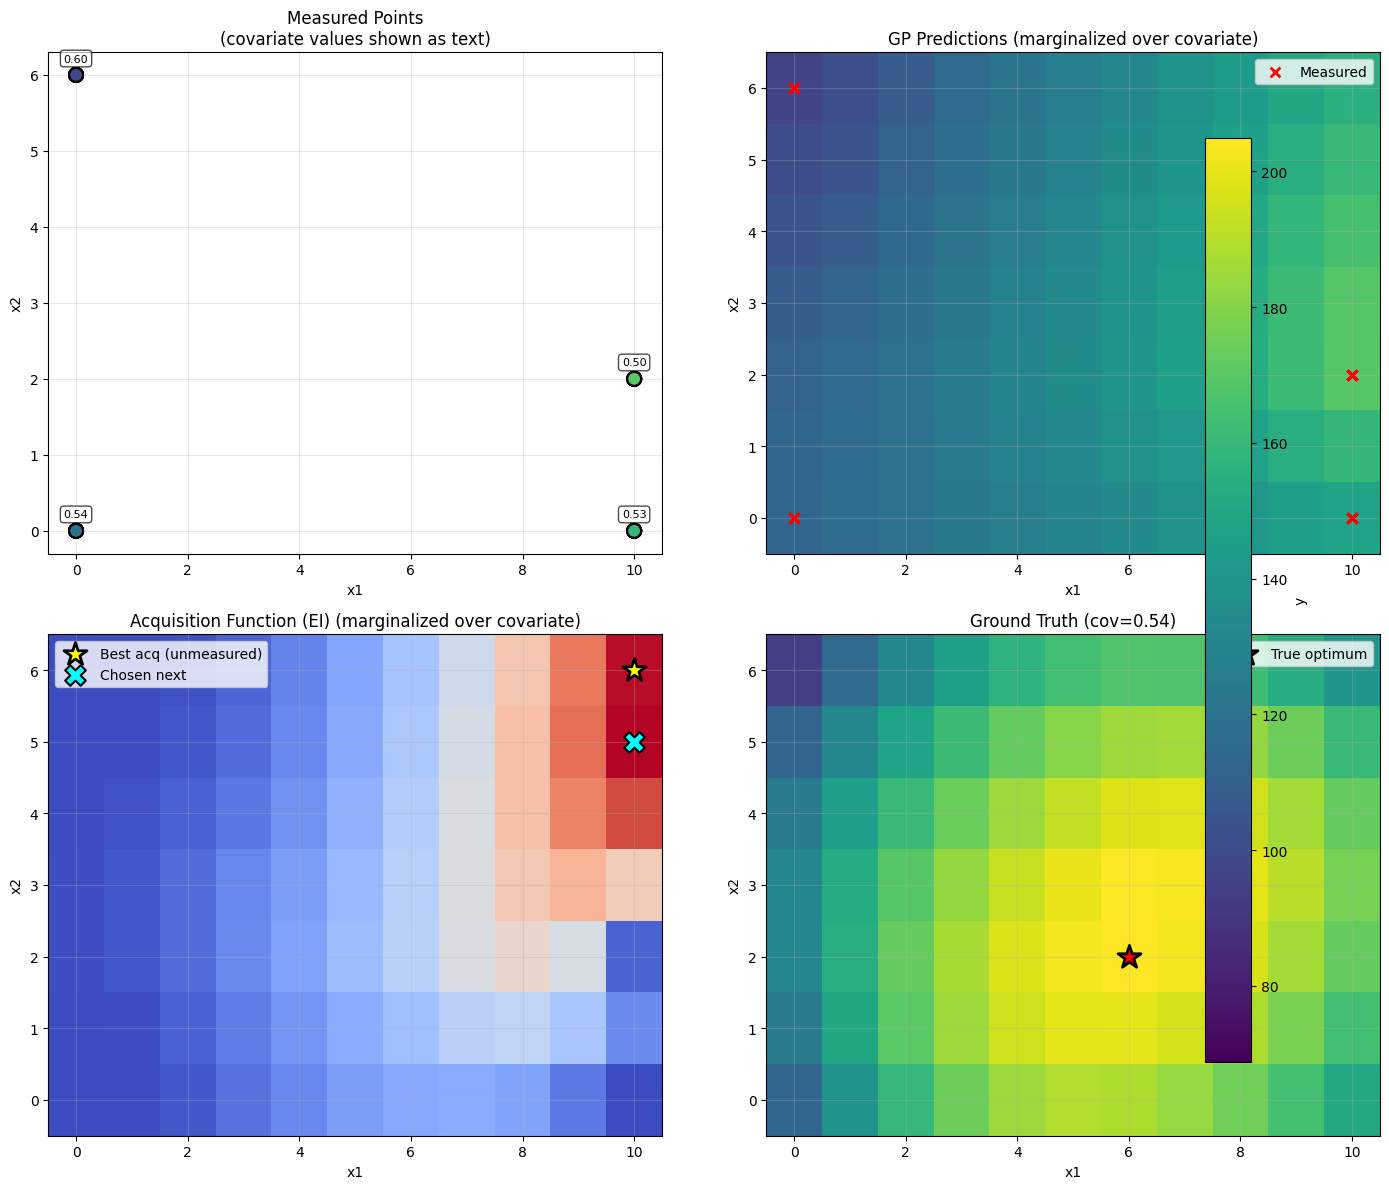

{'x1': np.float64(10.0), 'x2': np.float64(5.0)}
=== BO iteration 3/12 ===


sample: 100%|██████████| 1200/1200 [00:02<00:00, 469.16it/s, 7 steps of size 5.08e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.71      0.48      0.62      0.05      1.36    657.93      1.00
k_length[1]      1.44      0.57      1.42      0.53      2.36    452.91      1.00
k_length[2]      5.89      1.70      5.63      3.45      8.68    725.84      1.00
    k_scale      1.65      1.00      1.37      0.39      2.72    554.22      1.00
      noise      0.01      0.00      0.01      0.01      0.01    520.68      1.01

Computing robust acquisition over 1440 scenarios (72 grid points × 20 covariate samples)...
  best_f (scaled): 1.413416
  Acq values stats: min=0.000000, max=0.143896, mean=0.034213
  Robust acq stats: min=0.000000, max=0.093860
Computing robust acquisition over 1540 scenarios (77 grid points × 20 covariate samples)...
  best_f (scaled): 1.413416
  Acq values stats: min=0.000000, max=0.144495, mean=0.030550
  Robust acq stats: min=0.000000, max=0.092094


c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\rtm_pymmcore\agents\bo_optimization_gpax.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


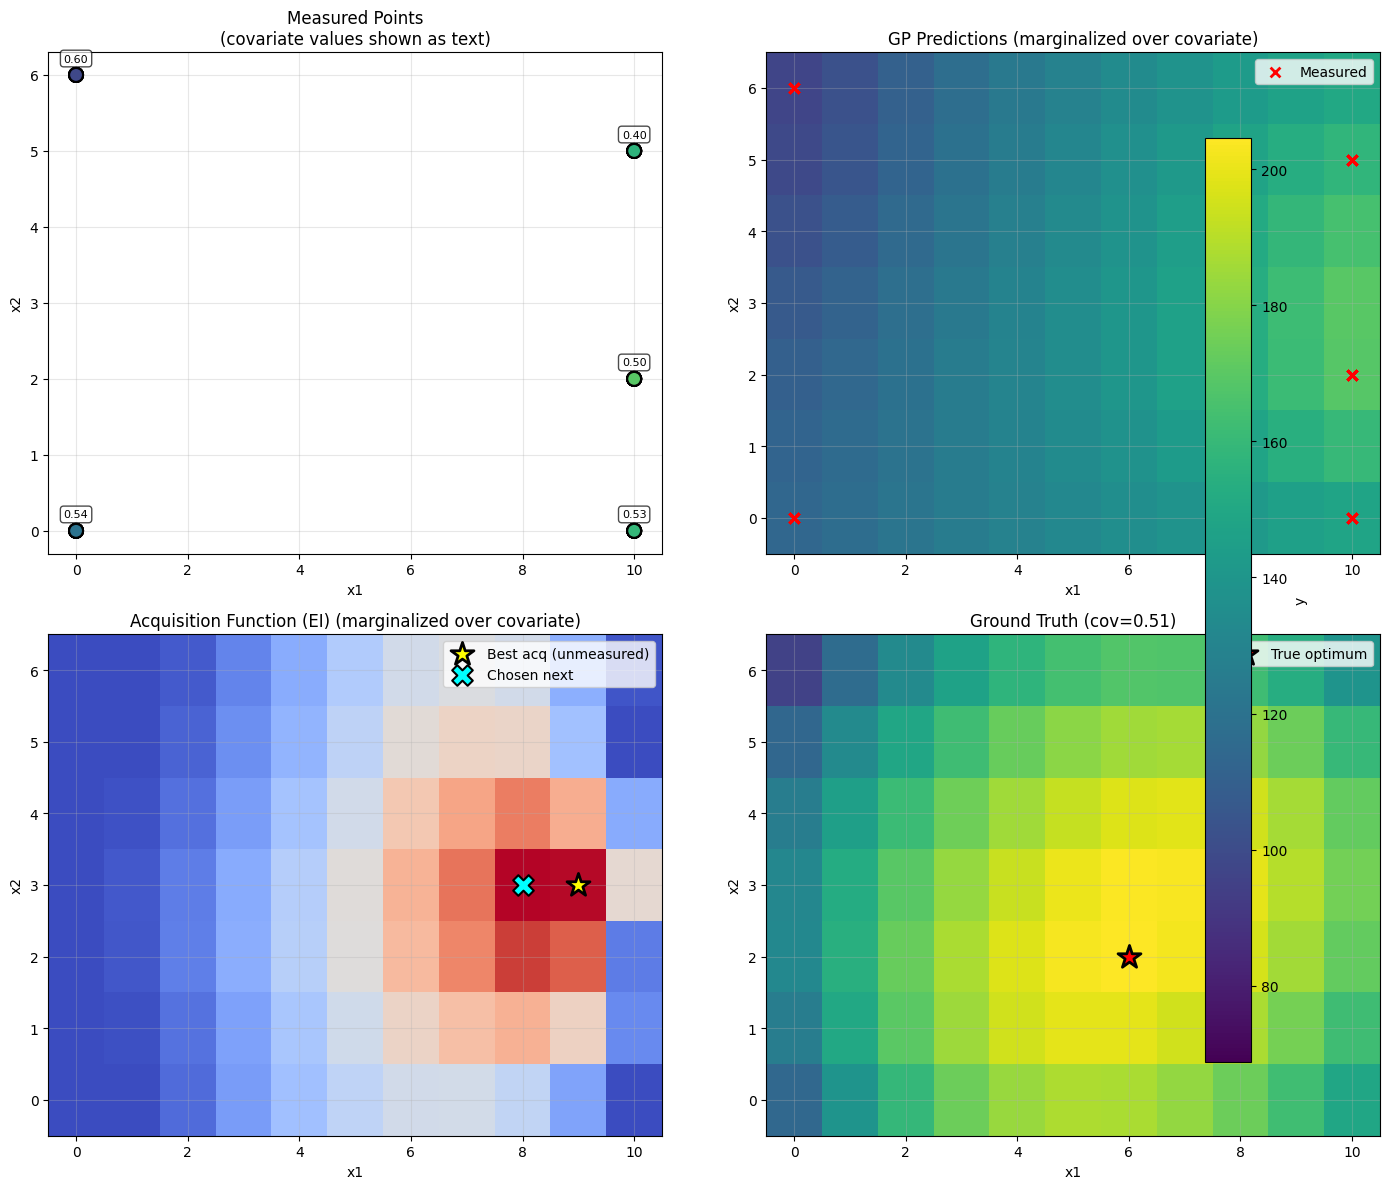

{'x1': np.float64(8.0), 'x2': np.float64(3.0)}
=== BO iteration 4/12 ===


sample: 100%|██████████| 1200/1200 [00:03<00:00, 394.74it/s, 15 steps of size 4.47e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.59      0.35      0.53      0.05      0.99    593.14      1.00
k_length[1]      1.42      0.62      1.42      0.35      2.32    457.06      1.00
k_length[2]      6.92      2.06      6.68      3.91     10.10    373.32      1.00
    k_scale      1.66      0.89      1.45      0.53      2.81    444.05      1.00
      noise      0.01      0.00      0.01      0.00      0.01    612.37      1.00

Computing robust acquisition over 1420 scenarios (71 grid points × 20 covariate samples)...
  best_f (scaled): 1.670410
  Acq values stats: min=0.000000, max=0.139026, mean=0.035464
  Robust acq stats: min=0.000000, max=0.116305
Computing robust acquisition over 1540 scenarios (77 grid points × 20 covariate samples)...
  best_f (scaled): 1.670410
  Acq values stats: min=0.000000, max=0.115573, mean=0.025911
  Robust acq stats: min=0.000000, max=0.100189


c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\rtm_pymmcore\agents\bo_optimization_gpax.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


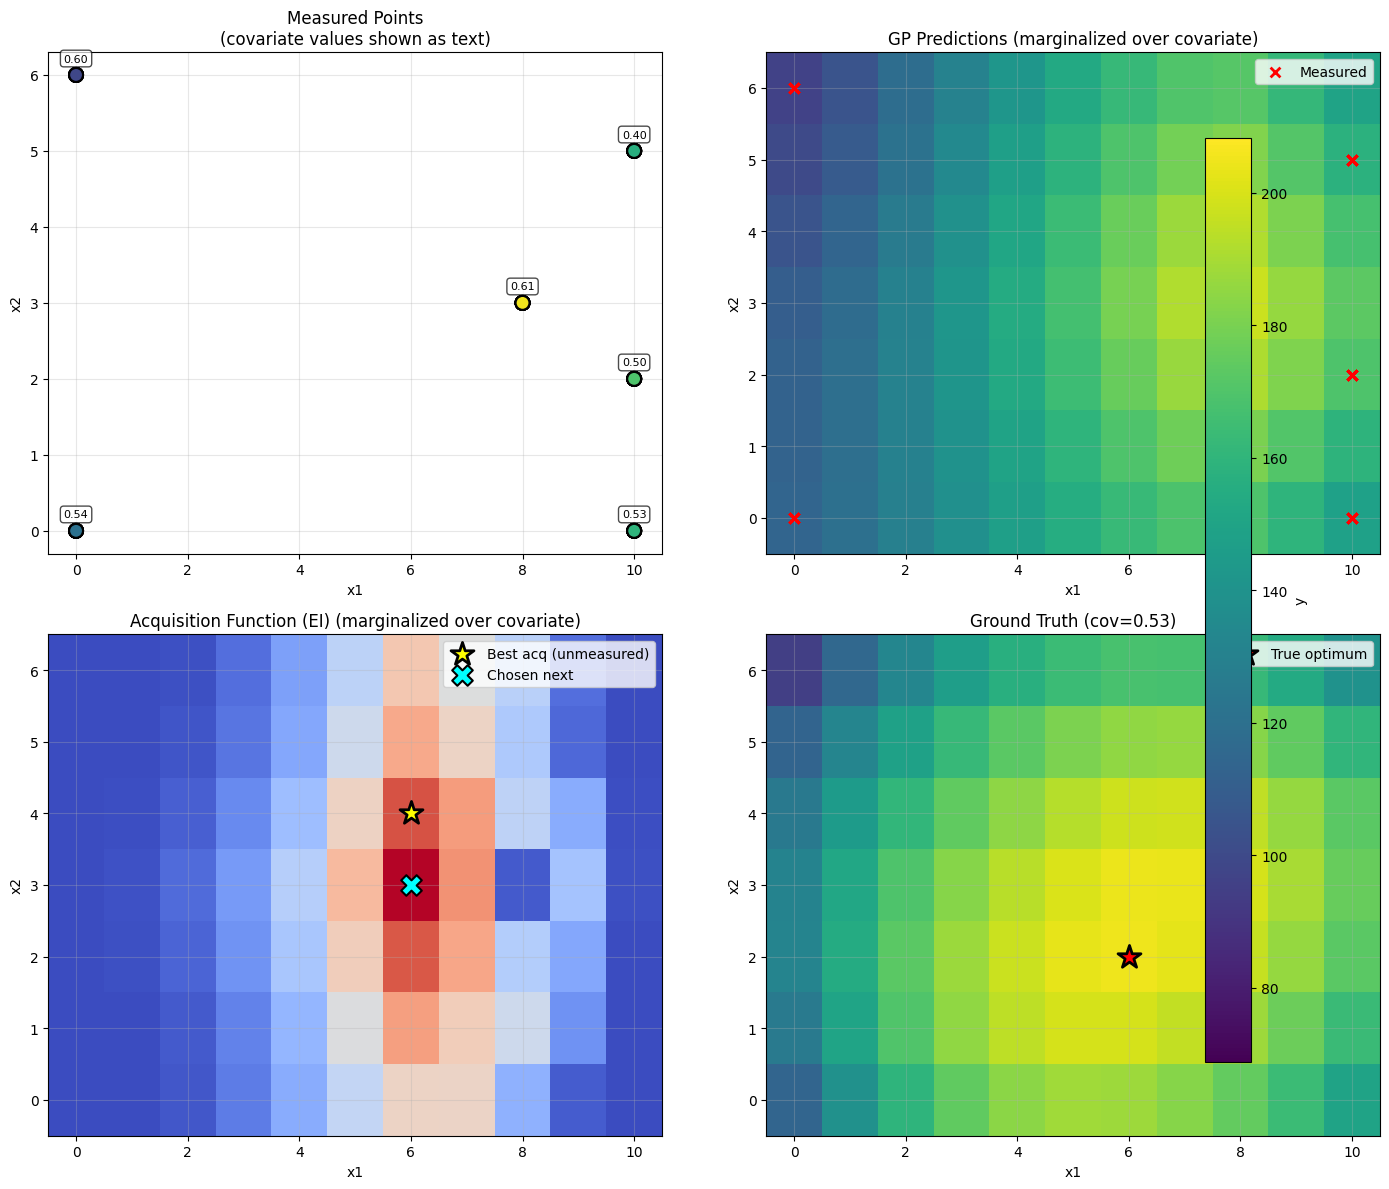

{'x1': np.float64(6.0), 'x2': np.float64(3.0)}
=== BO iteration 5/12 ===


sample: 100%|██████████| 1200/1200 [00:03<00:00, 386.28it/s, 7 steps of size 3.80e-01. acc. prob=0.90] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.91      0.52      0.81      0.17      1.61    336.07      1.00
k_length[1]      1.48      0.67      1.49      0.34      2.50    383.54      1.00
k_length[2]      7.85      2.32      7.49      4.09     11.33    425.18      1.00
    k_scale      1.81      1.03      1.53      0.57      3.20    452.77      1.00
      noise      0.01      0.00      0.01      0.00      0.01    635.61      1.00

Computing robust acquisition over 1400 scenarios (70 grid points × 20 covariate samples)...
  best_f (scaled): 1.377491
  Acq values stats: min=0.000000, max=0.139199, mean=0.025598
  Robust acq stats: min=0.000000, max=0.094311
Computing robust acquisition over 1540 scenarios (77 grid points × 20 covariate samples)...
  best_f (scaled): 1.377491
  Acq values stats: min=0.000000, max=0.108596, mean=0.018742
  Robust acq stats: min=0.000000, max=0.076921


c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\rtm_pymmcore\agents\bo_optimization_gpax.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


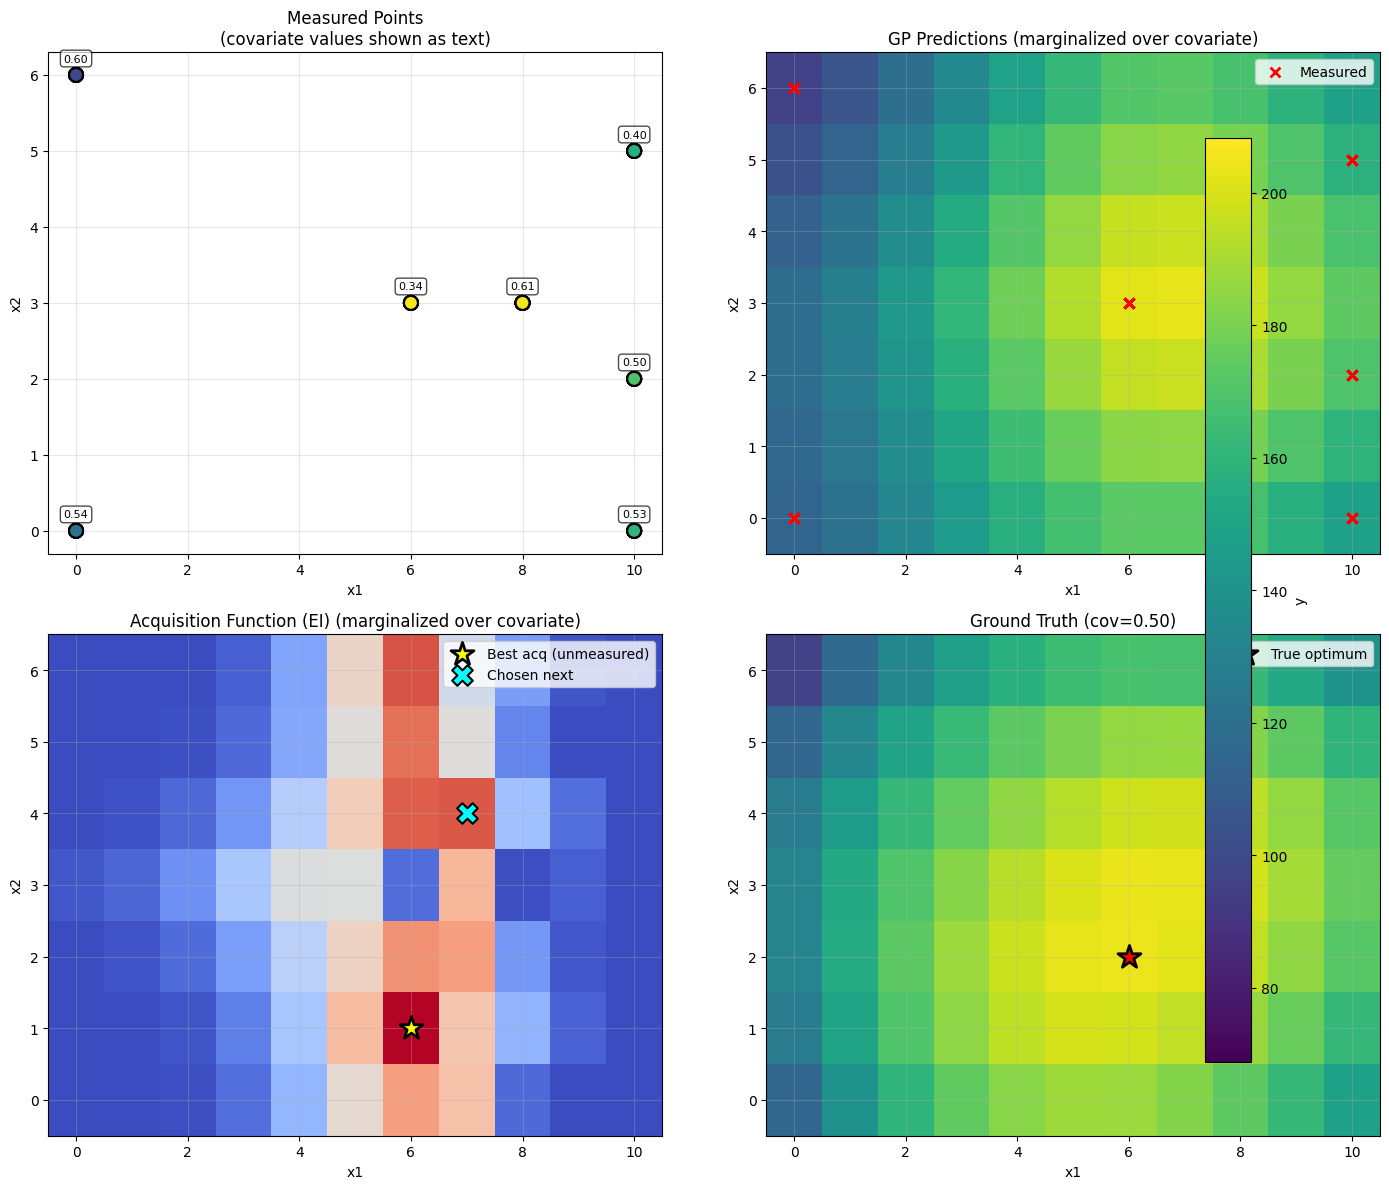

{'x1': np.float64(7.0), 'x2': np.float64(4.0)}
=== BO iteration 6/12 ===


sample: 100%|██████████| 1200/1200 [00:03<00:00, 340.00it/s, 7 steps of size 4.20e-01. acc. prob=0.91] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.07      0.45      1.00      0.36      1.77    554.62      1.00
k_length[1]      1.88      0.66      1.84      0.86      3.03    477.26      1.00
k_length[2]      9.20      2.75      8.74      4.72     13.06    564.96      1.00
    k_scale      2.13      1.31      1.75      0.60      3.92    511.60      1.00
      noise      0.01      0.00      0.01      0.00      0.01    744.86      1.00

Computing robust acquisition over 1380 scenarios (69 grid points × 20 covariate samples)...
  best_f (scaled): 1.233338
  Acq values stats: min=0.000000, max=0.062582, mean=0.004941
  Robust acq stats: min=0.000000, max=0.033789
Computing robust acquisition over 1540 scenarios (77 grid points × 20 covariate samples)...
  best_f (scaled): 1.233338
  Acq values stats: min=0.000000, max=0.041503, mean=0.002746
  Robust acq stats: min=0.000000, max=0.027265


c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\rtm_pymmcore\agents\bo_optimization_gpax.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


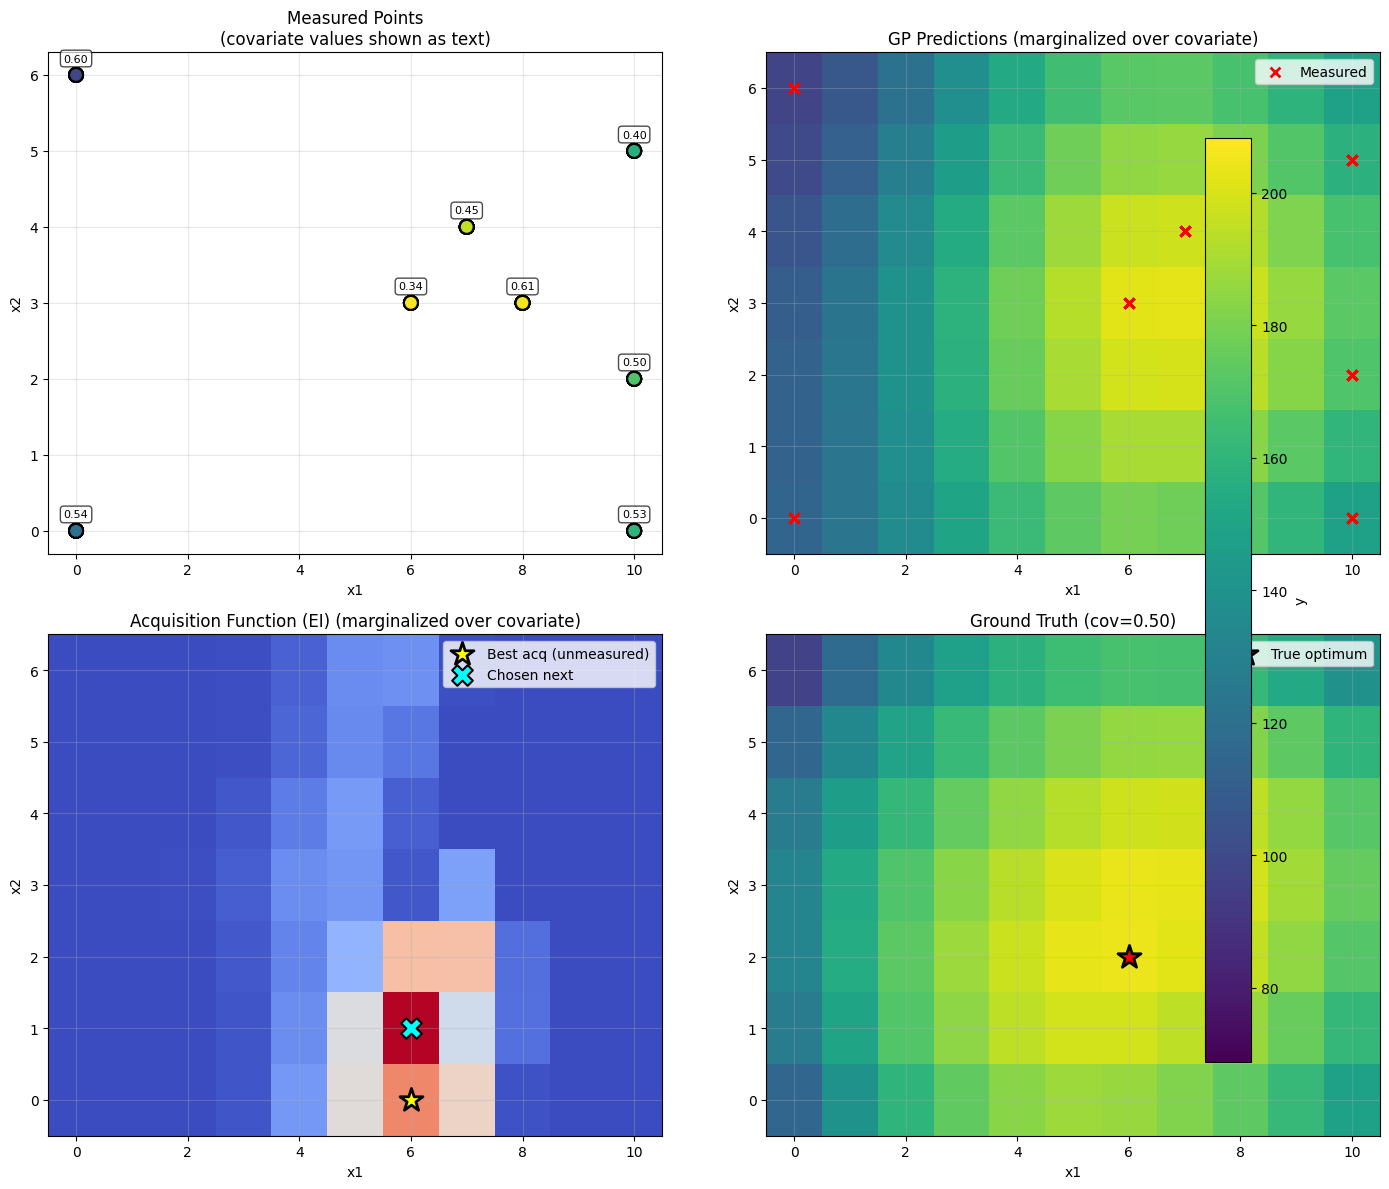

{'x1': np.float64(6.0), 'x2': np.float64(1.0)}
=== BO iteration 7/12 ===


sample: 100%|██████████| 1200/1200 [00:03<00:00, 335.56it/s, 7 steps of size 4.32e-01. acc. prob=0.93] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.16      0.43      1.11      0.52      1.84    321.00      1.00
k_length[1]      2.27      0.65      2.23      1.29      3.36    336.14      1.00
k_length[2]     10.12      2.94      9.72      4.98     14.14    324.43      1.00
    k_scale      2.61      1.65      2.16      0.55      4.67    265.21      1.00
      noise      0.01      0.00      0.01      0.00      0.01    875.97      1.00

Computing robust acquisition over 1360 scenarios (68 grid points × 20 covariate samples)...
  best_f (scaled): 1.230795
  Acq values stats: min=0.000000, max=0.017423, mean=0.000276
  Robust acq stats: min=0.000000, max=0.002509
Computing robust acquisition over 1540 scenarios (77 grid points × 20 covariate samples)...
  best_f (scaled): 1.230795
  Acq values stats: min=0.000000, max=0.007276, mean=0.000169
  Robust acq stats: min=0.000000, max=0.001451


c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\rtm_pymmcore\agents\bo_optimization_gpax.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


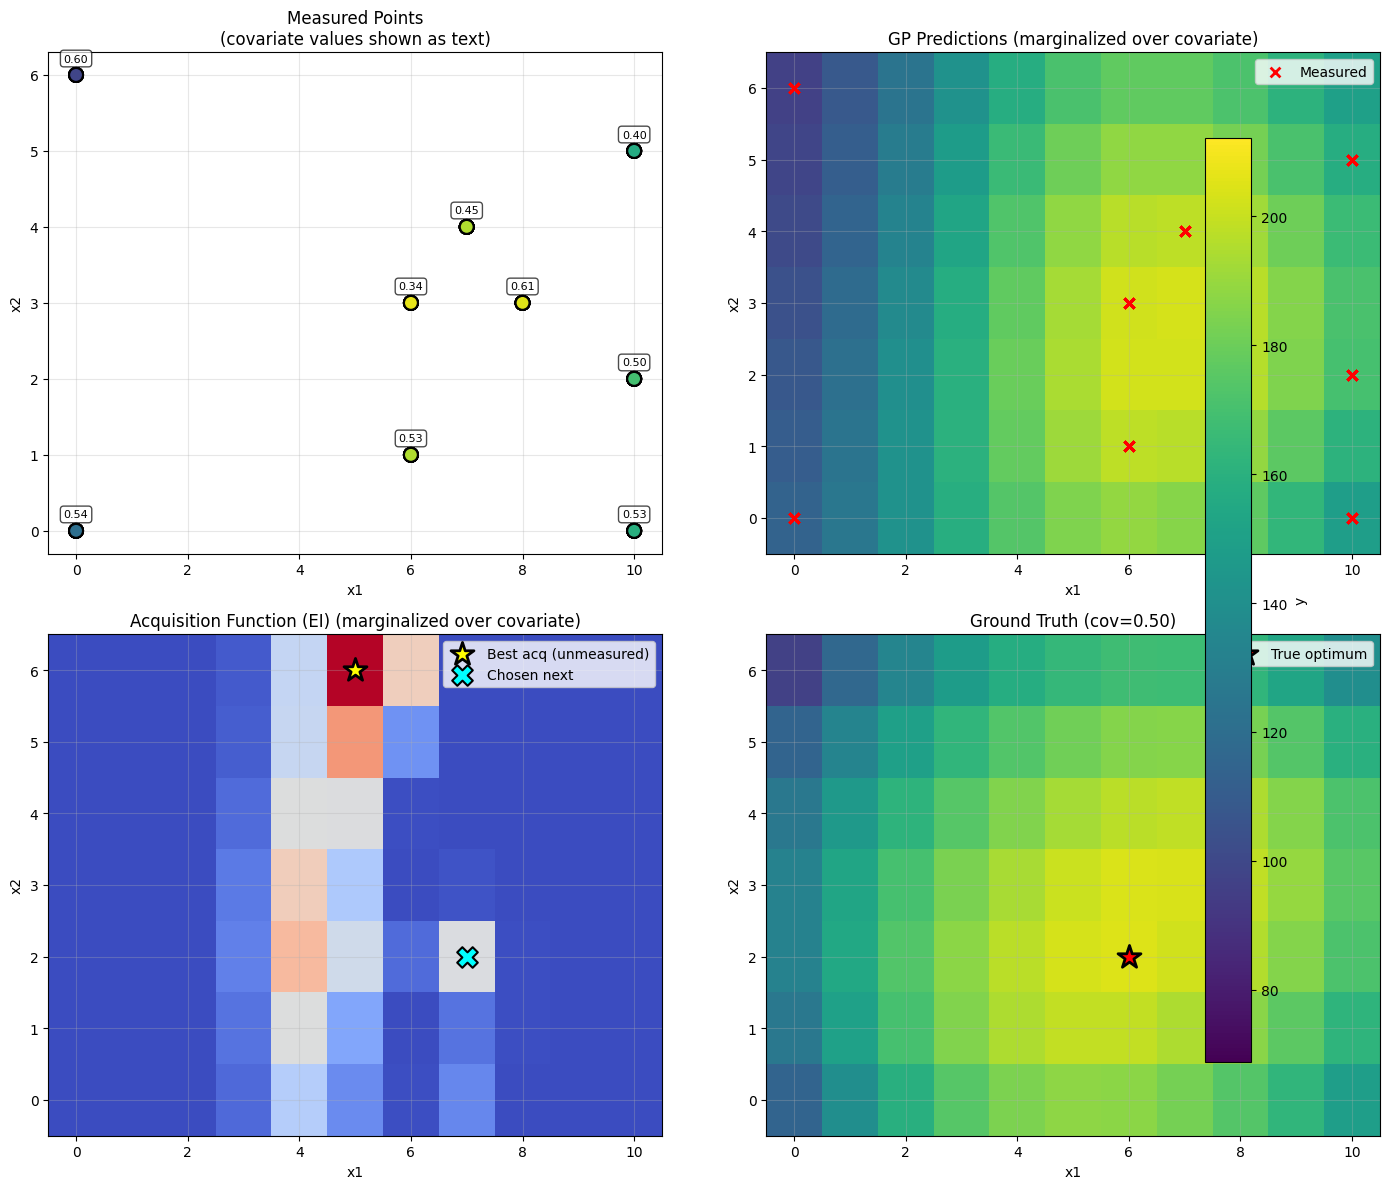

{'x1': np.float64(7.0), 'x2': np.float64(2.0)}
=== BO iteration 8/12 ===


sample: 100%|██████████| 1200/1200 [00:04<00:00, 287.89it/s, 15 steps of size 3.08e-01. acc. prob=0.92]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.35      0.48      1.29      0.63      2.16    310.30      1.01
k_length[1]      2.49      0.73      2.43      1.31      3.56    293.83      1.00
k_length[2]     10.04      3.02      9.68      5.45     14.83    456.66      1.00
    k_scale      3.06      2.11      2.43      0.62      5.71    314.19      1.01
      noise      0.01      0.00      0.01      0.00      0.01    754.44      1.00

Computing robust acquisition over 1340 scenarios (67 grid points × 20 covariate samples)...
  best_f (scaled): 1.138882
  Acq values stats: min=0.000000, max=0.000040, mean=0.000000
  Robust acq stats: min=0.000000, max=0.000002
Computing robust acquisition over 1540 scenarios (77 grid points × 20 covariate samples)...
  best_f (scaled): 1.138882
  Acq values stats: min=0.000000, max=0.000071, mean=0.000000
  Robust acq stats: min=0.000000, max=0.000004


c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\rtm_pymmcore\agents\bo_optimization_gpax.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


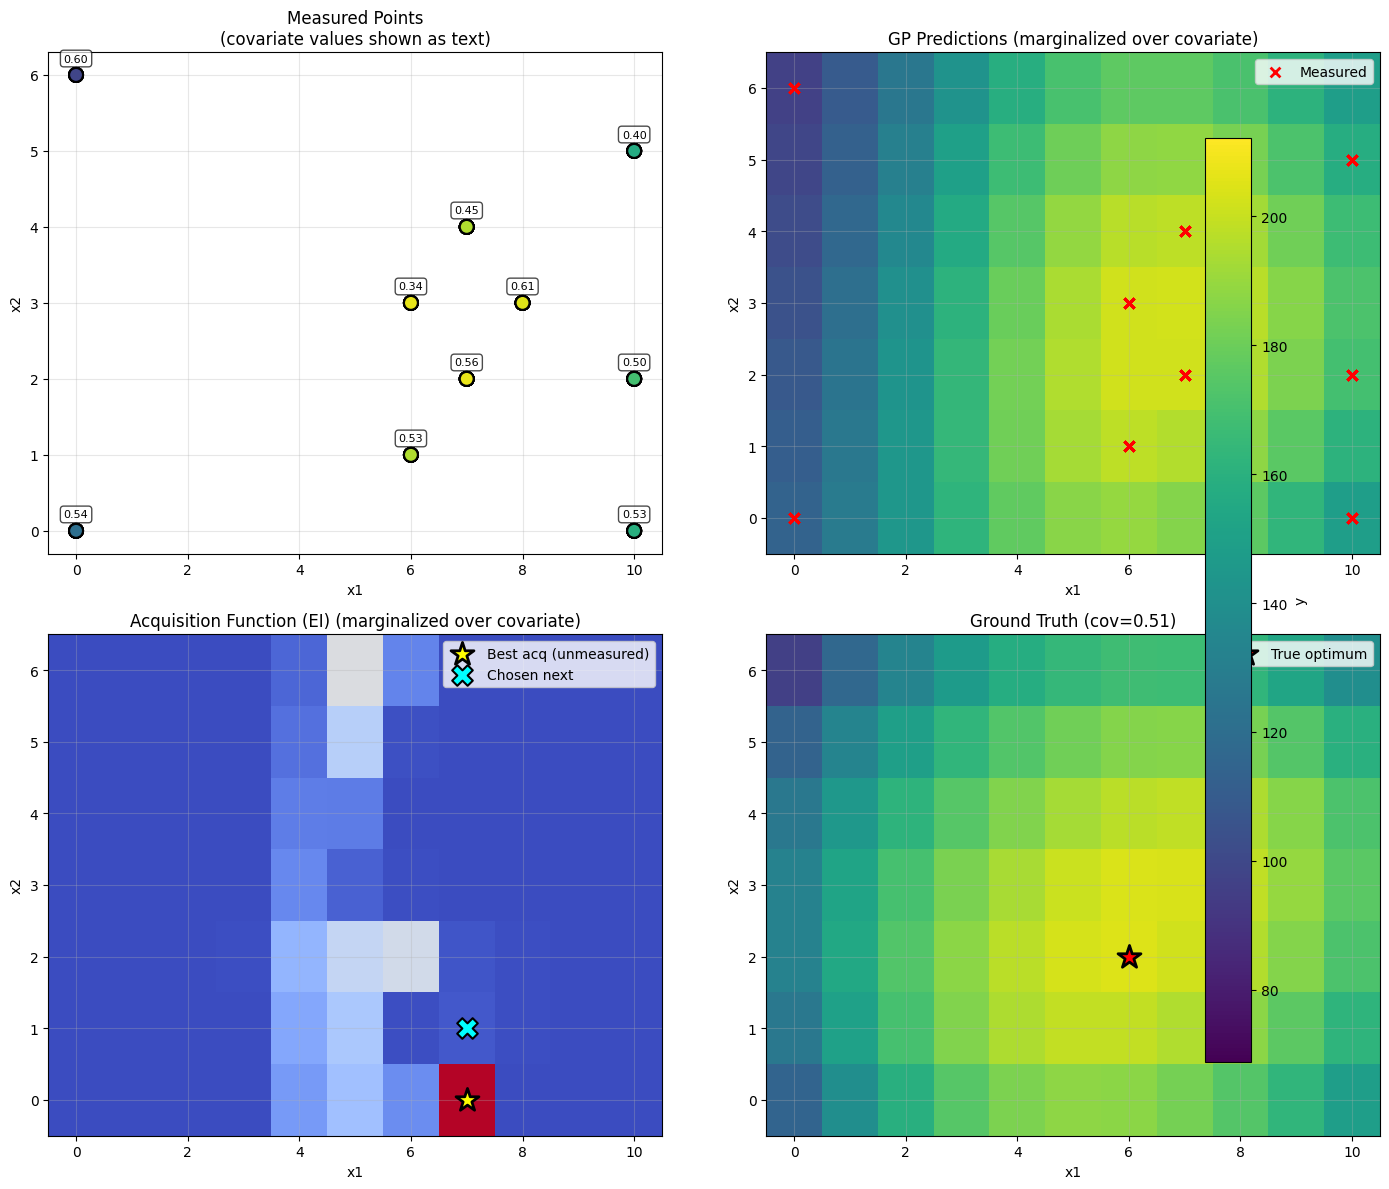

{'x1': np.float64(7.0), 'x2': np.float64(1.0)}
=== BO iteration 9/12 ===


sample: 100%|██████████| 1200/1200 [00:04<00:00, 271.59it/s, 15 steps of size 4.17e-01. acc. prob=0.92]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.49      0.46      1.45      0.72      2.16    241.24      1.01
k_length[1]      2.59      0.70      2.53      1.51      3.71    356.45      1.01
k_length[2]     10.67      3.17     10.31      5.66     15.29    432.07      1.00
    k_scale      3.54      2.50      2.90      0.79      6.41    251.75      1.01
      noise      0.01      0.00      0.01      0.00      0.01    714.88      1.00

Computing robust acquisition over 1320 scenarios (66 grid points × 20 covariate samples)...
  best_f (scaled): 1.118950
  Acq values stats: min=0.000000, max=0.000015, mean=0.000000
  Robust acq stats: min=0.000000, max=0.000002
Computing robust acquisition over 1540 scenarios (77 grid points × 20 covariate samples)...
  best_f (scaled): 1.118950
  Acq values stats: min=0.000000, max=0.000017, mean=0.000000
  Robust acq stats: min=0.000000, max=0.000002


c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\rtm_pymmcore\agents\bo_optimization_gpax.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


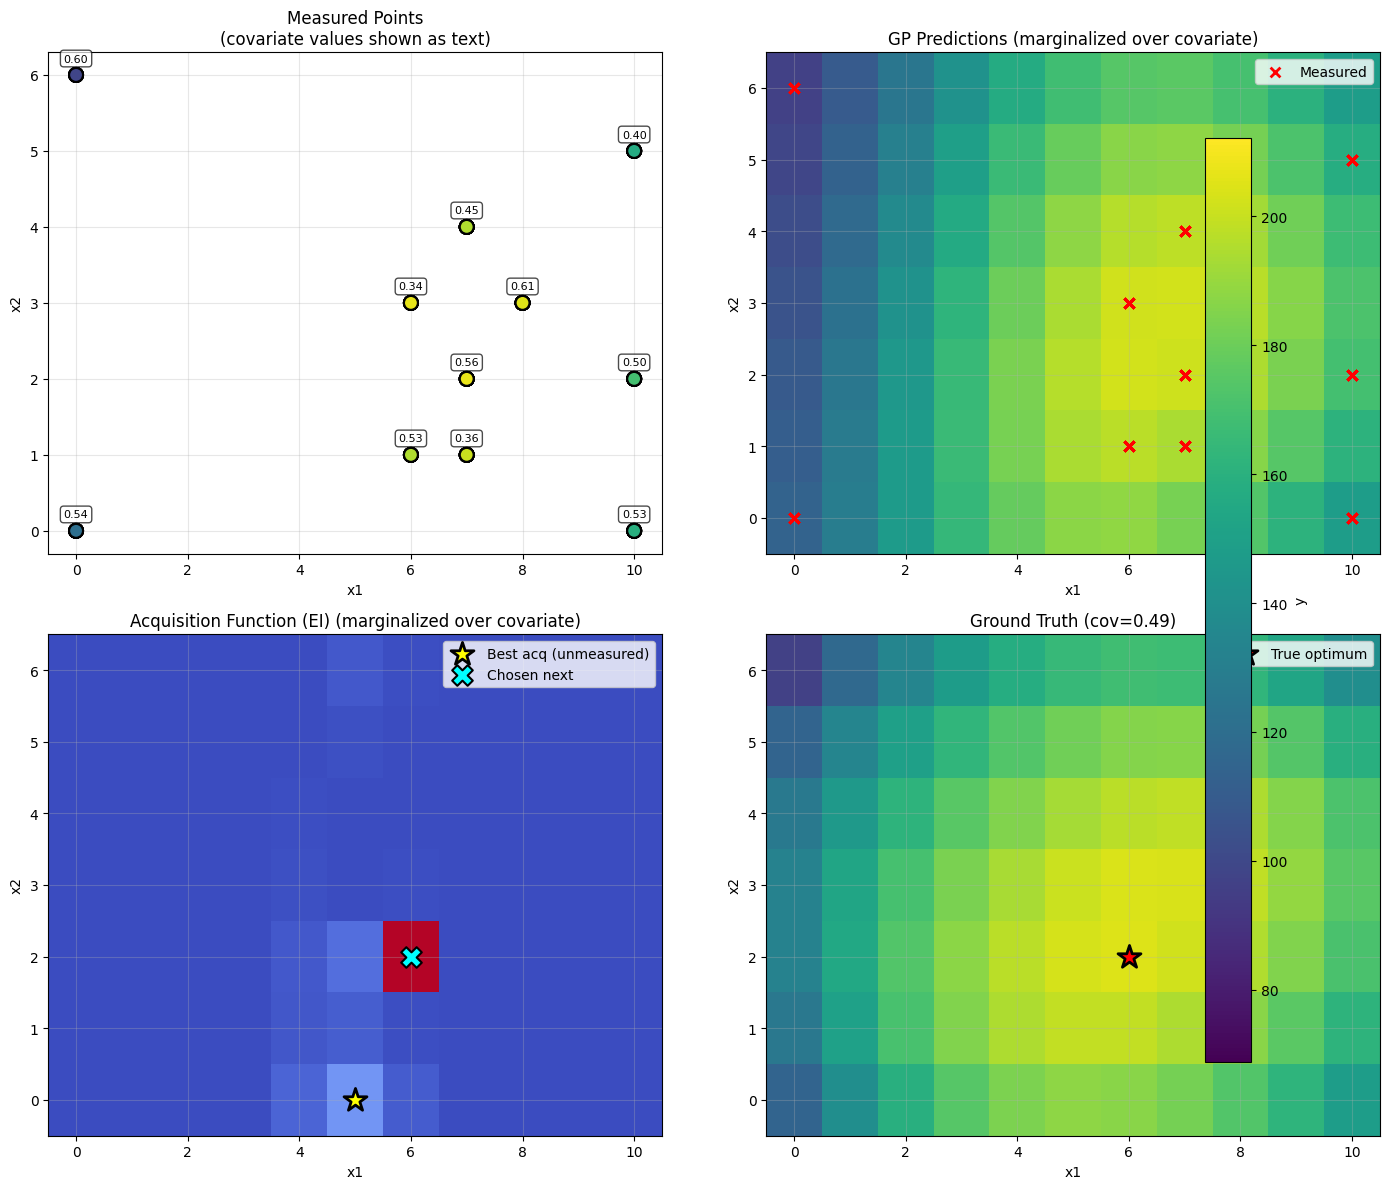

{'x1': np.float64(6.0), 'x2': np.float64(2.0)}
=== BO iteration 10/12 ===


sample: 100%|██████████| 1200/1200 [00:06<00:00, 197.26it/s, 15 steps of size 3.79e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.56      0.45      1.52      0.79      2.21    403.58      1.01
k_length[1]      2.71      0.70      2.67      1.55      3.76    393.76      1.00
k_length[2]     10.75      3.00     10.39      5.64     15.12    402.88      1.00
    k_scale      3.84      2.52      3.17      1.01      7.13    367.39      1.00
      noise      0.01      0.00      0.01      0.00      0.01    517.01      1.00

Computing robust acquisition over 1300 scenarios (65 grid points × 20 covariate samples)...
  best_f (scaled): 1.064682
  Acq values stats: min=0.000000, max=0.000000, mean=0.000000
  Robust acq stats: min=0.000000, max=0.000000
  EI is flat (max-min < 1e-6). Falling back to UCB for this round.
Computing robust acquisition over 1300 scenarios (65 grid points × 20 covariate samples)...
  best_f (scaled): 1.064682
  Acq values stats: min=-2.436210, max=0.958475, mean=-0.139441
  Robust acq stats: min=-1

c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\rtm_pymmcore\agents\bo_optimization_gpax.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


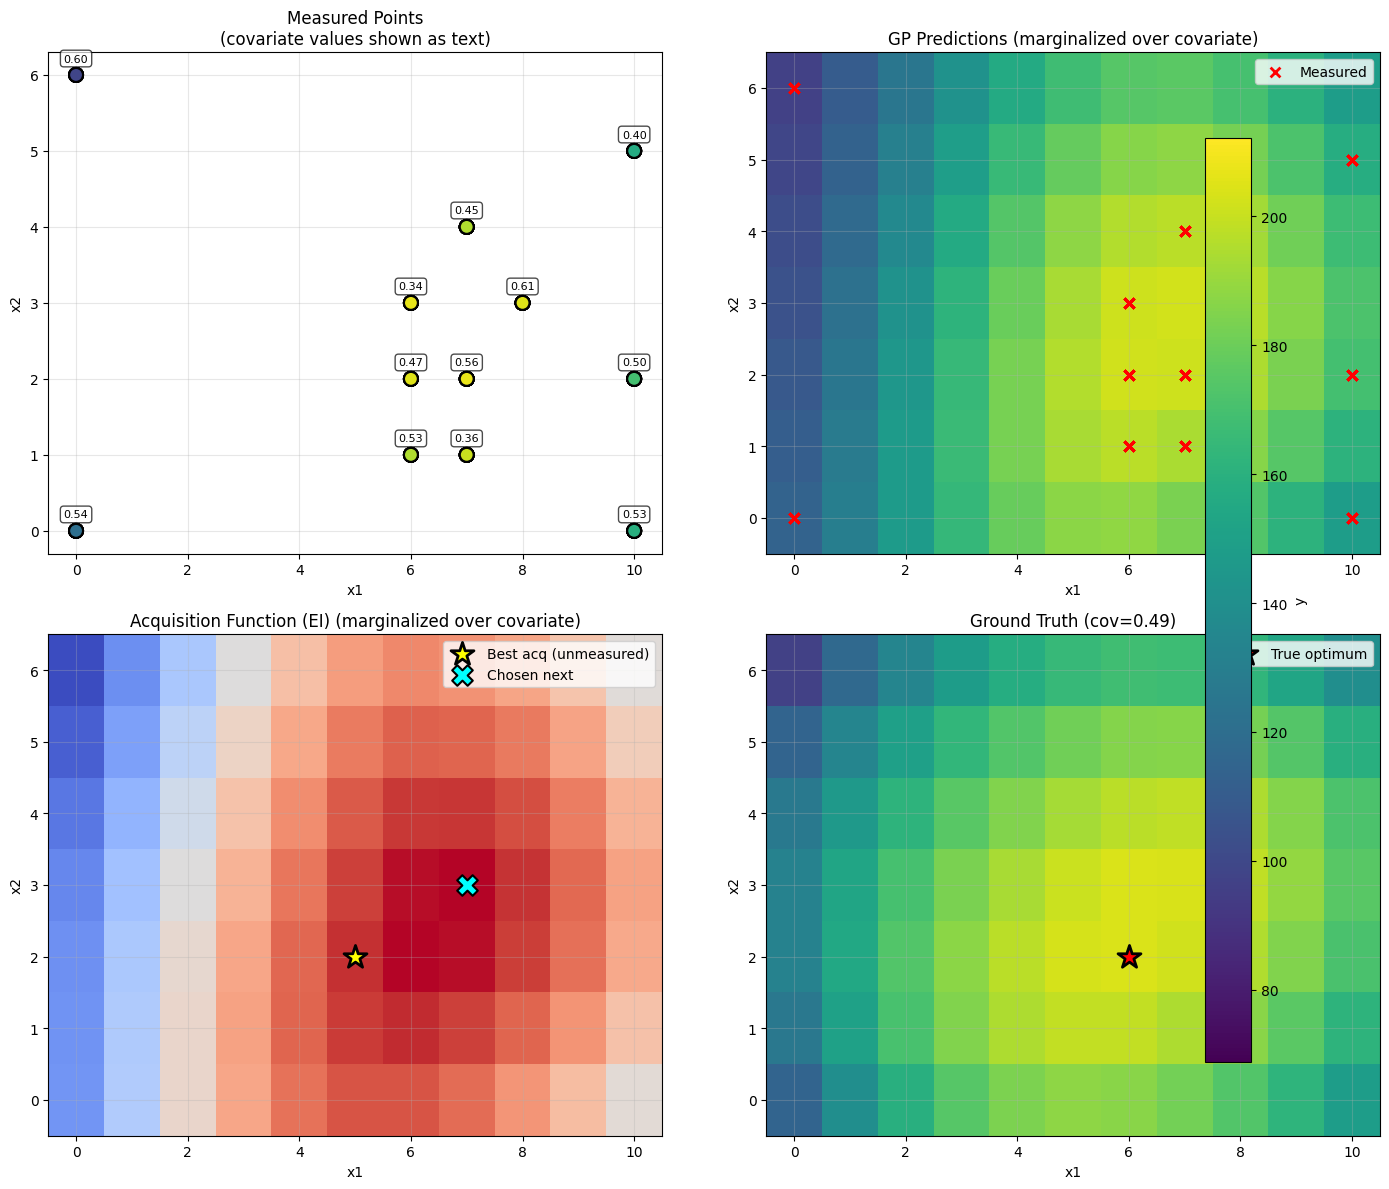

{'x1': np.float64(7.0), 'x2': np.float64(3.0)}
=== BO iteration 11/12 ===


sample: 100%|██████████| 1200/1200 [00:05<00:00, 226.13it/s, 15 steps of size 3.33e-01. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.61      0.46      1.56      0.91      2.30    355.63      1.00
k_length[1]      2.78      0.69      2.74      1.71      3.85    425.51      1.00
k_length[2]     11.48      3.08     11.19      6.33     15.99    521.85      1.00
    k_scale      4.11      2.69      3.37      1.04      7.57    414.66      1.00
      noise      0.01      0.00      0.01      0.01      0.01    483.04      1.00

Computing robust acquisition over 1280 scenarios (64 grid points × 20 covariate samples)...
  best_f (scaled): 1.049523
  Acq values stats: min=0.000000, max=0.000000, mean=0.000000
  Robust acq stats: min=0.000000, max=0.000000
  EI is flat (max-min < 1e-6). Falling back to UCB for this round.
Computing robust acquisition over 1280 scenarios (64 grid points × 20 covariate samples)...
  best_f (scaled): 1.049523
  Acq values stats: min=-2.544837, max=0.880335, mean=-0.233726
  Robust acq stats: min=-1

c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\rtm_pymmcore\agents\bo_optimization_gpax.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


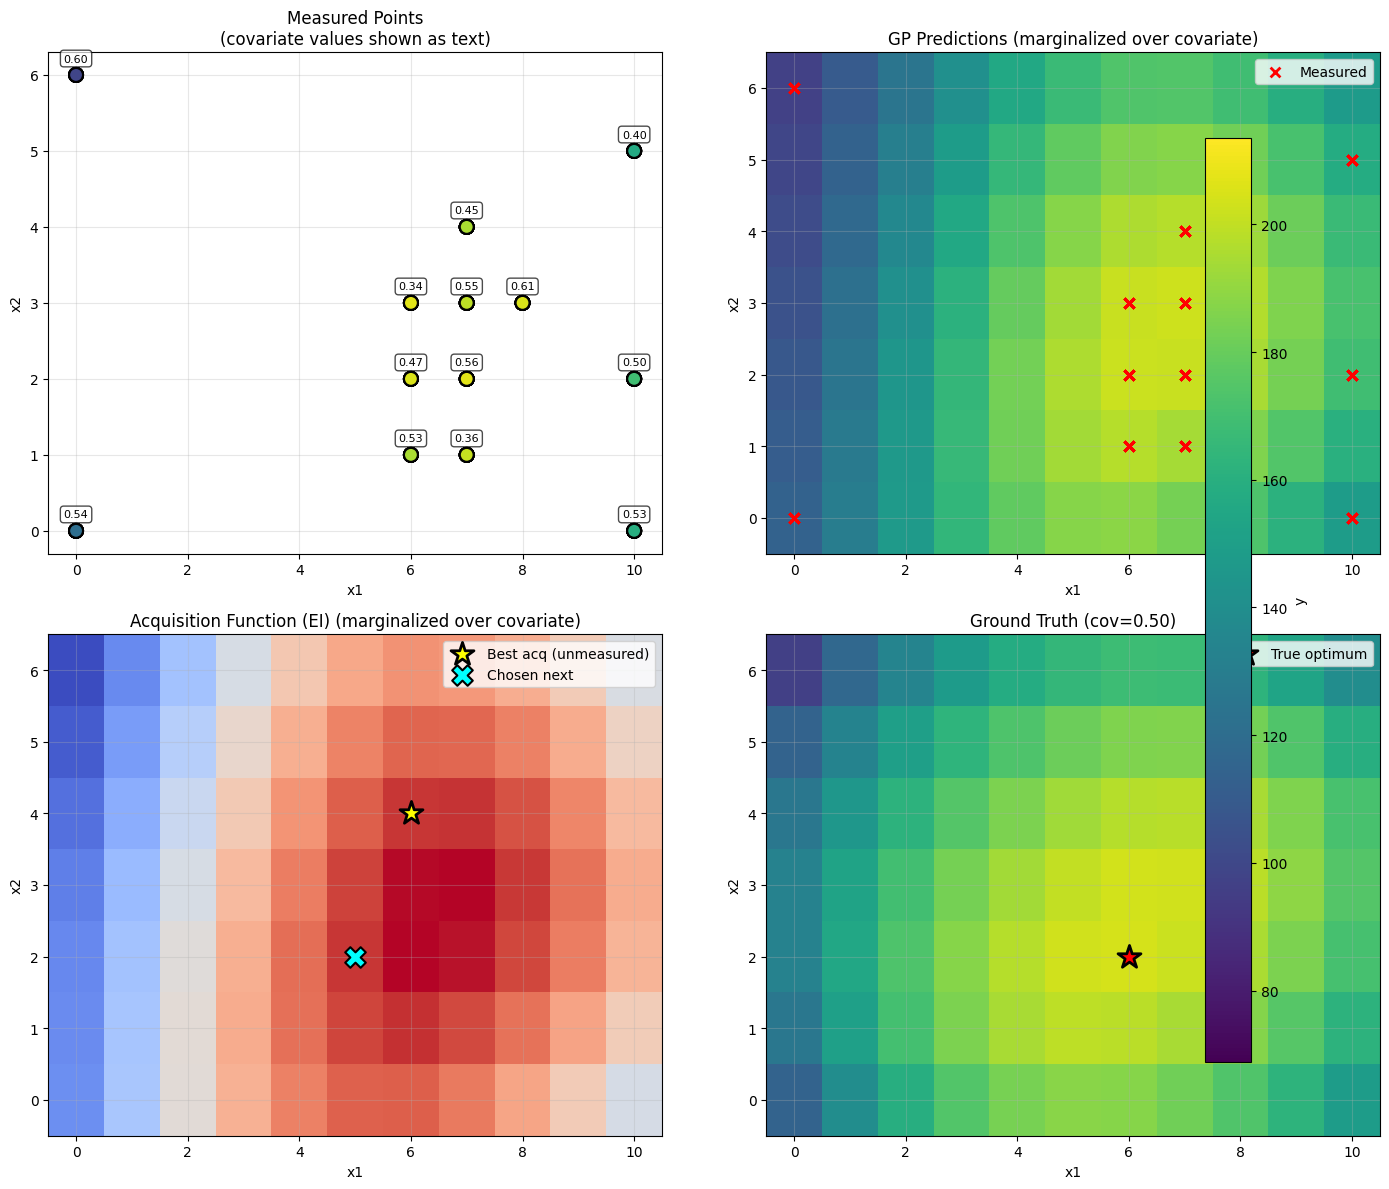

{'x1': np.float64(5.0), 'x2': np.float64(2.0)}
=== BO iteration 12/12 ===


sample: 100%|██████████| 1200/1200 [00:05<00:00, 212.59it/s, 15 steps of size 4.44e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.39      0.43      1.32      0.73      2.00    273.54      1.00
k_length[1]      2.71      0.72      2.66      1.68      3.89    268.49      1.00
k_length[2]     11.47      3.18     11.03      6.57     16.37    370.05      1.00
    k_scale      4.31      2.84      3.44      0.82      8.07    247.14      1.00
      noise      0.01      0.00      0.01      0.01      0.01    832.61      1.00

Computing robust acquisition over 1260 scenarios (63 grid points × 20 covariate samples)...
  best_f (scaled): 1.016569
  Acq values stats: min=0.000000, max=0.000000, mean=0.000000
  Robust acq stats: min=0.000000, max=0.000000
  EI is flat (max-min < 1e-6). Falling back to UCB for this round.
Computing robust acquisition over 1260 scenarios (63 grid points × 20 covariate samples)...
  best_f (scaled): 1.016569
  Acq values stats: min=-2.604416, max=0.880234, mean=-0.149568
  Robust acq stats: min=-2

c:\Users\Alex\Programmieren\01_git\PhD\rtm-pymmcore\rtm_pymmcore\agents\bo_optimization_gpax.py:820: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


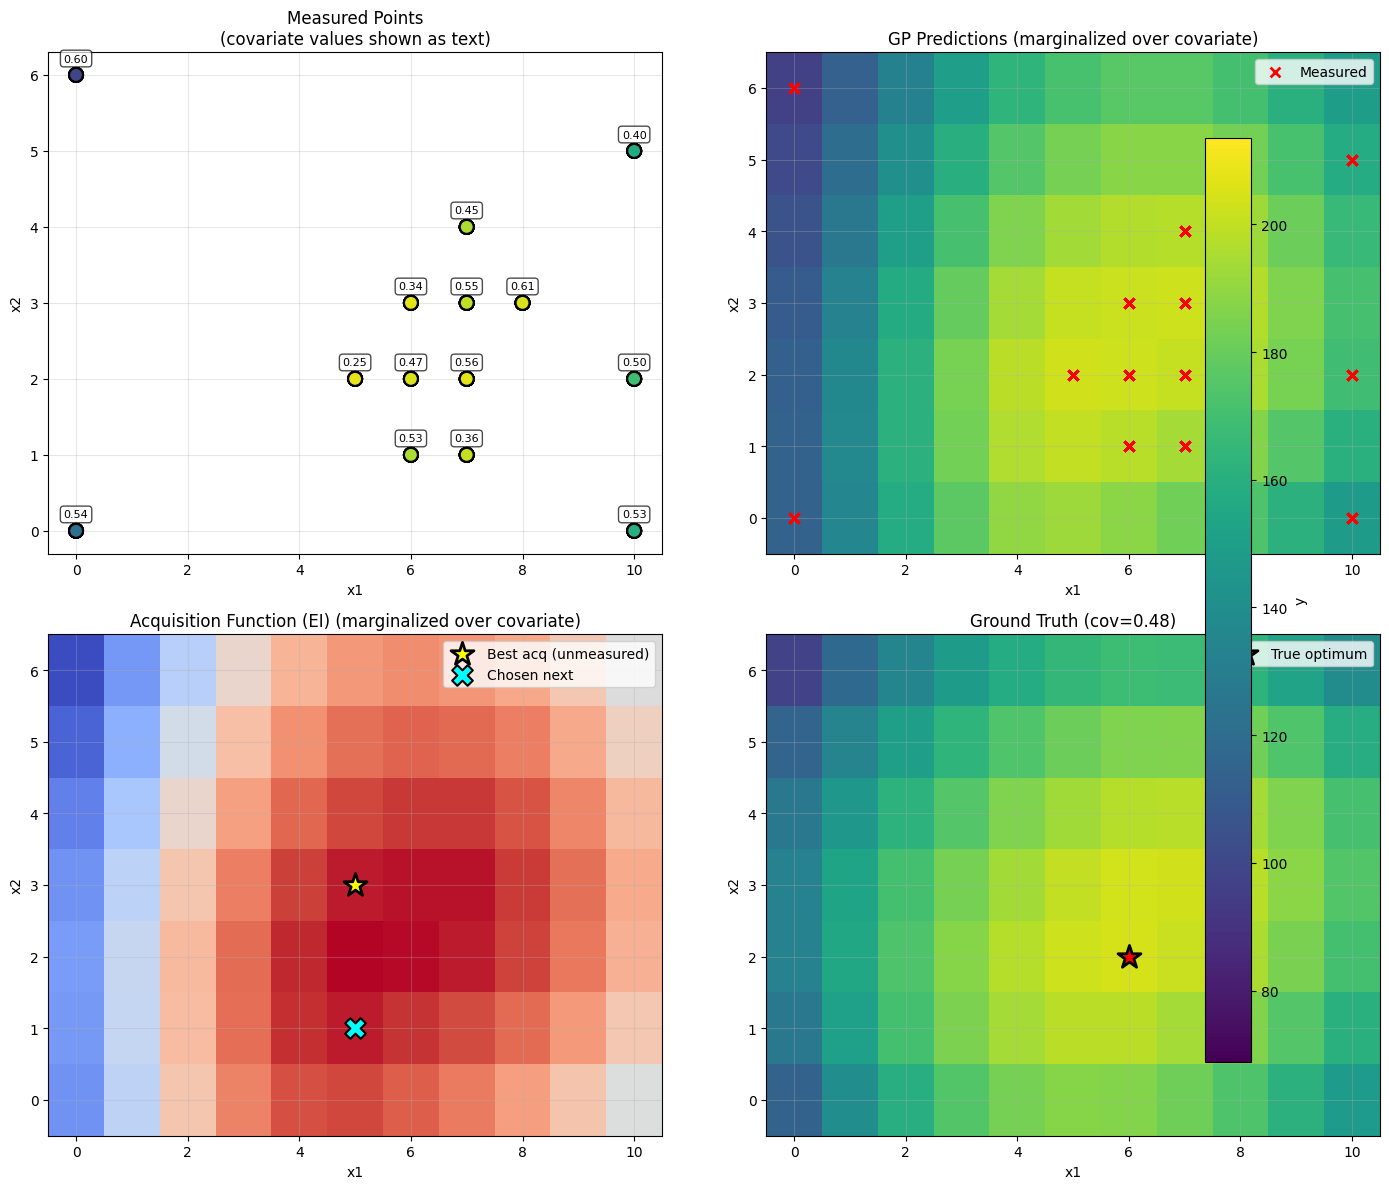

{'x1': np.float64(5.0), 'x2': np.float64(1.0)}


In [4]:
# simulate an example run with two steerable parameters (x1, x2),
# one non-steerable covariate (cov1), and a single 1D objective (y).
bo_params = [
    BO_Parameter(name="x1", bounds=(0.0, 10.0), param_type="float", spacing=1.0),
    BO_Parameter(name="x2", bounds=(0.0, 6.0), param_type="float", spacing=1.0),
]
bo_covariates = [
    BO_Covariate(name="cov1"),
]
bo_objective = BO_Objective(name="y", goal="maximize")

# Noise knob for the mock measurements (0.0 -> deterministic)
MOCK_NOISE_SCALE = 1.0


class MockMicroscope:
    def run_experiment(self, df_acquire):
        return mock_df_results(
            df_acquire=df_acquire, n_samples=10, noise_scale=MOCK_NOISE_SCALE
        )


class DemoBOptGPAX(BOptGPAX):
    def _create_df_acquire_for_exp_cycle(self, parameters: dict) -> pd.DataFrame:
        # One acquisition point per cycle; microscope will return multiple samples.
        return pd.DataFrame([parameters])

    def run(self):
        df_results = pd.DataFrame()

        # initial exploration
        X_init, _ = self._select_initial_samples(k=3)
        df_acquire_init = pd.DataFrame(
            X_init, columns=[p.name for p in self.parameters_to_optimize]
        )
        df_new_results = self.microscope.run_experiment(df_acquire_init)
        df_results = pd.concat([df_results, df_new_results], ignore_index=True)

        print(df_results)

        for e in range(self.n_iterations):
            print(f"=== BO iteration {e+1}/{self.n_iterations} ===")
            next_params = self._determine_next_parameters(df_results, verbose=True)
            print(next_params)

            df_acquire = pd.DataFrame([next_params])
            df_new_results = self.microscope.run_experiment(df_acquire)
            df_results = pd.concat([df_results, df_new_results], ignore_index=True)

            self.iteration += 1


bo_agent = DemoBOptGPAX(
    pipeline=(),
    microscope=MockMicroscope(),
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=12,
    acquisition_function="ei",  # try: "ei" or "ucb"
    ucb_beta=4.0,
    ei_xi=0.0,
)

bo_agent.run()

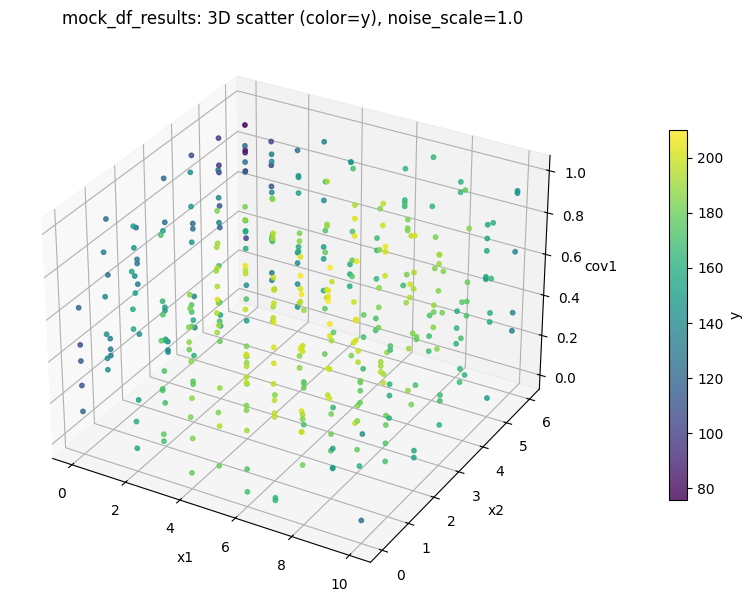

In [5]:
# 3D visualization of the mock data distribution
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)

# Build a full (x1,x2) grid and sample multiple cov1/y per point
x_total = bo_agent.x_total_linespace
df_acquire_grid = pd.DataFrame(x_total, columns=[p.name for p in bo_params])
df_mock = mock_df_results(
    df_acquire=df_acquire_grid, n_samples=5, noise_scale=MOCK_NOISE_SCALE
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    df_mock["x1"].values,
    df_mock["x2"].values,
    df_mock["cov1"].values,
    c=df_mock["y"].values,
    cmap="viridis",
    s=10,
    alpha=0.8,
)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("cov1")
ax.set_title(f"mock_df_results: 3D scatter (color=y), noise_scale={MOCK_NOISE_SCALE}")
cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.12)
cbar.set_label("y")
plt.show()